In [5]:
# ========== 4. 评价内容简单分类（按长度） ==========
def classify_by_length(length):
    if length < 100:
        return "短评"
    elif length < 300:
        return "中评"
    else:
        return "长评"

df["长度分类"] = df[col_word_count].apply(classify_by_length)

print("\n长度分类统计：")
print(df["长度分类"].value_counts())

# ========== 5. 提取重复评价（检测完全相同的评价内容） ==========
duplicate_content = df[df.duplicated(subset=[col_content], keep=False)]
if not duplicate_content.empty:
    print(f"\n发现 {len(duplicate_content)} 条重复评价内容（含首次出现）")
    # 可将重复内容单独保存到新 sheet
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name="清洗后数据", index=False)
        duplicate_content.to_excel(writer, sheet_name="重复评价内容", index=False)
    print(f"重复评价已额外保存至 sheet: 重复评价内容")
else:
    # 没有重复则直接保存全部
    df.to_excel(output_file, sheet_name="清洗后数据", index=False)
    print(f"\n没有发现完全重复的评价内容。")

# 如果想直接覆盖写入而没有重复sheet的情况
if duplicate_content.empty:
    df.to_excel(output_file, sheet_name="清洗后数据", index=False)

print(f"\n处理完成！结果已保存至: {output_file}")


原始数据形状: (44422, 3)
原始列名: ['评分（总分5分）(score)', '评价内容(content)', '字数']

前5行数据预览：
   评分（总分5分）(score)                                      评价内容(content)   字数
0                5  不错哦&hellip;&hellip;&hellip;&hellip;&hellip;&he...  960
1                5  汉 语:我来打酱油。 英 语:it's none of my business .i com...  902
2                5  我为什么喜欢在京东买东西，因为今天买明天就可以送到。我为什么每个商品的评价都一样，因为在京东...  757
3                5  猫咪不来   沦为坐垫。。。\n以下为复制：\n非常感谢京东商城给予的优质的服务，从仓储管理...  650
4                5  和此卖家交流，不由得精神为之一振，自觉七经八脉为之一畅，我在**买了这么多年，所谓阅商无数，...  528

使用列名 -> 评分: 评分（总分5分）(score), 评价内容: 评价内容(content), 字数: 字数

===== 统计分析 =====
总评价条数: 44422
评分分布:
评分（总分5分）(score)
1      960
2      250
3      528
4      852
5    41832
Name: count, dtype: int64
平均分: 4.85
中位数分: 5.0
最长评价字数: 960
最短评价字数: 1
平均评价字数: 26.4

长度分类统计：
长度分类
短评    43135
中评     1182
长评      105
Name: count, dtype: int64

发现 8993 条重复评价内容（含首次出现）
重复评价已额外保存至 sheet: 重复评价内容

处理完成！结果已保存至: 评价数据_处理后.xlsx


In [9]:
import pandas as pd
df = pd.read_excel(r"C:\Users\34919\jdc_oringi.xlsx")
import re
input_file = "jdc_oringi.xlsx"      # 输入的 Excel 文件名
output_file = "评价数据_处理后.xlsx"  # 输出的 Excel 文件名
sheet_name = 0                    # 工作表索引或名称，0 表示第一个表
df = pd.read_excel(input_file, sheet_name=sheet_name)
print("原始数据形状:", df.shape)
print("原始列名:", df.columns.tolist())
print("\n前5行数据预览：")
print(df.head())
col_score = "评分（总分5分）(score)"   # 根据你给的示例
col_content = "评价内容(content)"
col_word_count = "字数"

# 如果列名不完全一致，可以用模糊匹配或手动指定
# 这里做一个简单的自动匹配（可选）
for col in df.columns:
    if "评分" in str(col) or "score" in str(col).lower():
        col_score = col
    if "评价内容" in str(col) or "content" in str(col).lower():
        col_content = col
    if "字数" in str(col) or "word" in str(col).lower():
        col_word_count = col

print(f"\n使用列名 -> 评分: {col_score}, 评价内容: {col_content}, 字数: {col_word_count}")

原始数据形状: (44422, 3)
原始列名: ['评分（总分5分）(score)', '评价内容(content)', '字数']

前5行数据预览：
   评分（总分5分）(score)                                      评价内容(content)   字数
0                5  不错哦&hellip;&hellip;&hellip;&hellip;&hellip;&he...  960
1                5  汉 语:我来打酱油。 英 语:it's none of my business .i com...  902
2                5  我为什么喜欢在京东买东西，因为今天买明天就可以送到。我为什么每个商品的评价都一样，因为在京东...  757
3                5  猫咪不来   沦为坐垫。。。\n以下为复制：\n非常感谢京东商城给予的优质的服务，从仓储管理...  650
4                5  和此卖家交流，不由得精神为之一振，自觉七经八脉为之一畅，我在**买了这么多年，所谓阅商无数，...  528

使用列名 -> 评分: 评分（总分5分）(score), 评价内容: 评价内容(content), 字数: 字数


In [10]:
# ========== 1. 数据清洗（删除重复行：字数>10）==========

print("开始数据清洗...")

# 删除全为空的行
df.dropna(how="all", inplace=True)

# 删除评价内容为空或仅为空白字符的行
df.dropna(subset=[col_content], inplace=True)
df = df[df[col_content].astype(str).str.strip() != ""]

# 计算评价内容的真实字数
df["实际字数"] = df[col_content].astype(str).apply(lambda x: len(x))

# 查看重复情况
duplicate_count = df.duplicated(subset=[col_content], keep=False).sum()
print(f"发现重复的评价内容（含首次）：{duplicate_count} 条")

# 找出所有重复的评价内容（不含首次）
duplicate_rows = df[df.duplicated(subset=[col_content], keep="first")]
long_duplicates = duplicate_rows[duplicate_rows["实际字数"] > 10]
print(f"其中字数>10的重复行：{len(long_duplicates)} 条")

# 删除：重复的 且 字数 > 10 的行
df = df[~((df.duplicated(subset=[col_content], keep="first")) & (df["实际字数"] > 10))]

# 重置索引
df.reset_index(drop=True, inplace=True)

print(f"清洗后最终数据行数：{len(df)}")

开始数据清洗...
发现重复的评价内容（含首次）：8993 条
其中字数>10的重复行：4407 条
清洗后最终数据行数：40015


In [11]:
# ========== 3. 基础统计分析 ==========
print("\n===== 统计分析 =====")
print(f"总评价条数: {len(df)}")
print(f"评分分布:\n{df[col_score].value_counts().sort_index()}")
print(f"平均分: {df[col_score].mean():.2f}")
print(f"中位数分: {df[col_score].median()}")
print(f"最长评价字数: {df[col_word_count].max()}")
print(f"最短评价字数: {df[col_word_count].min()}")
print(f"平均评价字数: {df[col_word_count].mean():.1f}")


===== 统计分析 =====
总评价条数: 40015
评分分布:
评分（总分5分）(score)
1      921
2      245
3      511
4      833
5    37505
Name: count, dtype: int64
平均分: 4.84
中位数分: 5.0
最长评价字数: 960
最短评价字数: 1
平均评价字数: 26.1


In [12]:
# 1. 按具体字数统计（每个字数有多少条评论）
word_count_stats = df["实际字数"].value_counts().sort_index()
print("\n【按具体字数统计】")
print(word_count_stats.to_string())


【按具体字数统计】
实际字数
1       407
2      1236
3       975
4       844
5       801
6       766
7       815
8       919
9       984
10     1335
11     1312
12     1519
13     1522
14     1502
15     1439
16     1339
17     1216
18     1178
19     1096
20     1106
21     1061
22      940
23      898
24      904
25      845
26      796
27      707
28      689
29      611
30      614
31      534
32      515
33      503
34      465
35      408
36      396
37      311
38      342
39      323
40      310
41      258
42      244
43      220
44      202
45      193
46      193
47      164
48      162
49      108
50      134
51      147
52      142
53      103
54      107
55      115
56       95
57       88
58       91
59       75
60       84
61       75
62       92
63       76
64       81
65       66
66       65
67       51
68       69
69       47
70       43
71       49
72       44
73       33
74       43
75       42
76       35
77       45
78       47
79       38
80       40
81       36
82       33


In [15]:
# ==================== 删除 100 字以上的评论 ====================
print("\n========== 删除 100 字以上的评论 ==========")

before_filter = len(df)
df = df[df["实际字数"] <= 100].copy()
after_filter = len(df)

deleted_count = before_filter - after_filter
print(f"删除前总评论数：{before_filter}")
print(f"删除 100 字以上的评论：{deleted_count} 条")
print(f"保留 100 字及以下的评论：{after_filter} 条")
print(f"保留占比：{after_filter / before_filter * 100:.2f}%")

# 重置索引
df.reset_index(drop=True, inplace=True)

# ==================== 统计剩余数据的字数分布 ====================
print("\n========== 剩余评论字数统计 ==========")

# 按具体字数统计
word_count_stats = df["实际字数"].value_counts().sort_index()
print("\n【按具体字数统计】")
print(word_count_stats.to_string())

# 分段统计（100字以内细分）
bins_100 = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels_100 = ['1-10字', '11-20字', '21-30字', '31-40字', '41-50字', 
              '51-60字', '61-70字', '71-80字', '81-90字', '91-100字']

df["字数分段"] = pd.cut(df["实际字数"], bins=bins_100, labels=labels_100, right=True)
segment_stats = df["字数分段"].value_counts().sort_index()

print("\n【按字数分段统计（10字一档）】")
for seg, count in segment_stats.items():
    pct = count / len(df) * 100
    print(f"  {seg}: {count} 条 ({pct:.1f}%)")

# ==================== 按评分统计 ====================
print("\n【按评分统计】")
score_stats = df[col_score].value_counts().sort_index()
for score, count in score_stats.items():
    pct = count / len(df) * 100
    print(f"  评分 {score} 分：{count} 条 ({pct:.1f}%)")

# ==================== 保存结果 ====================
output_file = "评价数据_100字及以下.xlsx"
df.to_excel(output_file, index=False)
print(f"\n已保存到：{output_file}")


========== 删除 100 字以上的评论 ==========
删除前总评论数：38998
删除 100 字以上的评论：0 条
保留 100 字及以下的评论：38998 条
保留占比：100.00%

========== 剩余评论字数统计 ==========

【按具体字数统计】
实际字数
1       407
2      1236
3       975
4       844
5       801
6       766
7       815
8       919
9       984
10     1335
11     1312
12     1519
13     1522
14     1502
15     1439
16     1339
17     1216
18     1178
19     1096
20     1106
21     1061
22      940
23      898
24      904
25      845
26      796
27      707
28      689
29      611
30      614
31      534
32      515
33      503
34      465
35      408
36      396
37      311
38      342
39      323
40      310
41      258
42      244
43      220
44      202
45      193
46      193
47      164
48      162
49      108
50      134
51      147
52      142
53      103
54      107
55      115
56       95
57       88
58       91
59       75
60       84
61       75
62       92
63       76
64       81
65       66
66       65
67       51
68       69
69       47
70       43
71     

In [18]:
import pandas as pd

# ==================== 读取已筛选好的文件 ====================
input_file = "评价数据_100字及以下.xlsx"
df1 = pd.read_excel(input_file)

# 自动匹配评分列名
col_score = None
for col in df1.columns:
    if "评分" in str(col) or "score" in str(col).lower():
        col_score = col
        break

print(f"使用评分列：{col_score}")

# ==================== 按评分统计 ====================
print("\n========== 按评分统计（100字及以下评论） ==========")

# 1. 各评分数量统计
score_counts = df1[col_score].value_counts().sort_index()
print("\n【各评分数量】")
for score, count in score_counts.items():
    print(f"  评分 {score} 分：{count} 条")

# 2. 各评分占比
print("\n【各评分占比】")
total = len(df1)
for score, count in score_counts.items():
    pct = count / total * 100
    print(f"  评分 {score} 分：{count} 条 ({pct:.2f}%)")

# 3. 各评分的平均字数
print("\n【各评分的平均字数】")
score_word_avg = df1.groupby(col_score)["实际字数"].mean().sort_index()
for score, avg_word in score_word_avg.items():
    print(f"  评分 {score} 分：平均 {avg_word:.1f} 字")

# 4. 各评分的字数中位数
print("\n【各评分的字数中位数】")
score_word_median = df1.groupby(col_score)["实际字数"].median().sort_index()
for score, median_word in score_word_median.items():
    print(f"  评分 {score} 分：中位数 {median_word:.0f} 字")

# ==================== 更详细的统计表 ====================
print("\n========== 详细统计表 ==========")

# 创建统计汇总表
stats_summary = pd.DataFrame({
    "评论条数": score_counts,
    "占比(%)": (score_counts / total * 100).round(2),
    "平均字数": score_word_avg.round(1),
    "中位数字数": score_word_median,
    "最短板评(字)": df1.groupby(col_score)["实际字数"].min(),
    "最长评(字)": df1.groupby(col_score)["实际字数"].max()
})

print(stats_summary)

# ==================== 保存统计结果 ====================
output_file = "按评分统计结果100.xlsx"
stats_summary.to_excel(output_file)
print(f"\n统计结果已保存到：{output_file}")

# # 同时保存每个评分的详细评论（可选）
# for score in df1[col_score].unique():
#     score_df1 = df1[df1[col_score] == score]
#     score_df1.to_excel(f"评分{score}分_评论.xlsx", index=False)
#     print(f"  评分 {score} 分的 {len(score_df1)} 条评论已保存到：评分{score}分_评论.xlsx")

使用评分列：评分（总分5分）(score)

========== 按评分统计（100字及以下评论） ==========

【各评分数量】
  评分 1 分：822 条
  评分 2 分：235 条
  评分 3 分：486 条
  评分 4 分：784 条
  评分 5 分：36671 条

【各评分占比】
  评分 1 分：822 条 (2.11%)
  评分 2 分：235 条 (0.60%)
  评分 3 分：486 条 (1.25%)
  评分 4 分：784 条 (2.01%)
  评分 5 分：36671 条 (94.03%)

【各评分的平均字数】
  评分 1 分：平均 31.0 字
  评分 2 分：平均 26.5 字
  评分 3 分：平均 25.0 字
  评分 4 分：平均 23.9 字
  评分 5 分：平均 21.8 字

【各评分的字数中位数】
  评分 1 分：中位数 24 字
  评分 2 分：中位数 20 字
  评分 3 分：中位数 20 字
  评分 4 分：中位数 18 字
  评分 5 分：中位数 18 字

========== 详细统计表 ==========
                  评论条数  占比(%)  平均字数  中位数字数  最短板评(字)  最长评(字)
评分（总分5分）(score)                                            
1                  822   2.11  31.0   24.0        1      99
2                  235   0.60  26.5   20.0        2      95
3                  486   1.25  25.0   20.0        2      97
4                  784   2.01  23.9   18.0        1     100
5                36671  94.03  21.8   18.0        1     100

统计结果已保存到：按评分统计结果100.xlsx


In [20]:
import pandas as pd

# 读取文件
df = pd.read_excel("评价数据_100字及以下.xlsx")

# 找到评分列和字数列
score_col = [col for col in df.columns if '评分' in str(col)][0]
word_col = [col for col in df.columns if '字数' in str(col)][0]

# 1-4分全取
df_1_4 = df[df[score_col] <= 4]

# 5分按规则抽样
df_5 = df[df[score_col] == 5]

# 定义规则
rules = [
    (df_5[word_col] <= 10, 1500),
    ((df_5[word_col] >= 11) & (df_5[word_col] <= 20), 1500),
    ((df_5[word_col] >= 21) & (df_5[word_col] <= 30), 1000),
    ((df_5[word_col] >= 31) & (df_5[word_col] <= 40), 1000),
    ((df_5[word_col] >= 41) & (df_5[word_col] <= 50), 1000),
    (df_5[word_col] >= 51, None)
]

sampled_parts = []
for condition, n in rules:
    subset = df_5[condition]
    if n is None or len(subset) <= n:
        sampled_parts.append(subset)
    else:
        sampled_parts.append(subset.sample(n=n, random_state=42))

df_5_sampled = pd.concat(sampled_parts)

# 合并保存
df_final = pd.concat([df_1_4, df_5_sampled])
df_final.to_excel("评价数据_抽取结果.xlsx", index=False)

print(f"完成！共 {len(df_final)} 条")

完成！共 10627 条


In [21]:
df_final

,评分（总分5分）(score),评价内容(content),字数,实际字数,字数分段
10,4,一分钱一分货吧，一个坏点，好在我不是写轮眼。看中护眼这个噱头，还有个惊喜就是内置音响的护耳功...,100,100,91-100字
12,4,收到时候背包颜色与页面介绍有些误差 稍偏粉，整体还不错，没想到的是不是很厚，有些小失望。里...,100,100,91-100字
14,4,第一：打开包装后发现，产品的白色包装盒表面的封胶带是被破坏过的，但我没有立即投诉，岁一度怀疑...,100,100,91-100字
18,1,东西付过钱好几天不发货，我们要退款，点过申请了，过了几天怎么显示收货完成，钱也没退，东西也没...,99,99,91-100字
34,1,京东有@人的嫌疑，头天晚上显示第二天早上8点钟进行秒杀，可是等来的秒杀竟然比头天晚上贵10块...,99,99,91-100字
...,...,...,...,...,...
2631,5,不错，很漂亮，很轻快，老公很喜欢，物流很快，快递员服务态度很好，送货上门，棒棒哒，还会继续关...,51,51,51-60字
2632,5,宝贝收到特别满意，质量出乎意料的好，包装的很好，没有任何破损没有一点异味，很厚重，物流公司服...,51,51,51-60字
2633,5,非常好，单位给配了一双黑色的，双十一活动又买一双，还很合适，运动健身穿他非常舒服，超级合计，...,51,51,51-60字
2635,5,之前用的是三星s7+\n在系统上没什么差别，流畅了许多。\n手机屏幕大气了许多，颜色很漂亮\...,51,51,51-60字


In [22]:
import pandas as pd

# 读取文件
df = pd.read_excel("评价数据_抽取结果.xlsx")

# 找到评分列
score_col = [col for col in df.columns if '评分' in str(col)][0]

# 统计
print("=" * 50)
print("分数分布统计")
print("=" * 50)

total = len(df)
print(f"\n总条数：{total}\n")

for score, count in df[score_col].value_counts().sort_index().items():
    pct = count / total * 100
    bar = "█" * int(pct / 2)
    print(f"{score} 分：{count:6} 条 ({pct:5.2f}%) {bar}")

分数分布统计

总条数：10627

1 分：   822 条 ( 7.74%) ███
2 分：   235 条 ( 2.21%) █
3 分：   486 条 ( 4.57%) ██
4 分：   784 条 ( 7.38%) ███
5 分：  8300 条 (78.10%) ███████████████████████████████████████


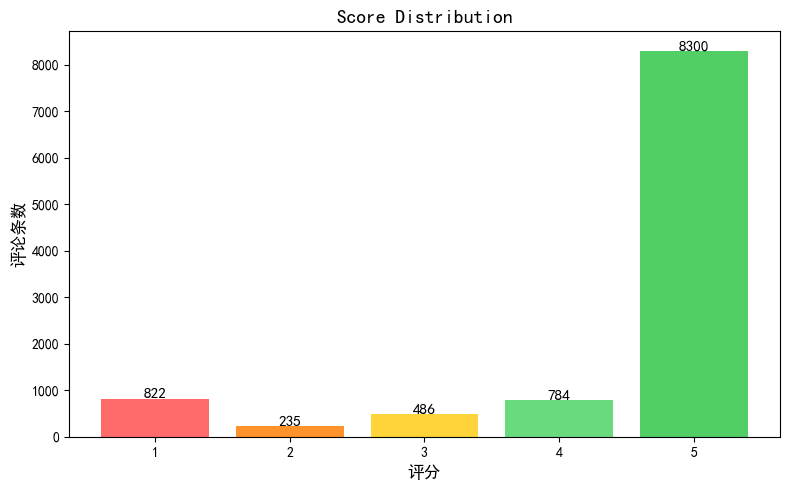

1-5分统计：
  1分：822 条 (7.74%)
  2分：235 条 (2.21%)
  3分：486 条 (4.57%)
  4分：784 条 (7.38%)
  5分：8300 条 (78.10%)


In [26]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # 读取数据
# df = pd.read_excel("评价数据_抽取结果.xlsx")

# 找到评分列
score_col = [col for col in df.columns if '评分' in str(col)][0]

# 统计1-5分数量
score_counts = df[score_col].value_counts().sort_index()

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 画柱状图
plt.figure(figsize=(8, 5))
bars = plt.bar(score_counts.index.astype(str), score_counts.values, 
               color=['#ff6b6b', '#ff922b', '#ffd43b', '#69db7e', '#51cf66'])

plt.xlabel('评分', fontsize=12)
plt.ylabel('评论条数', fontsize=12)
plt.title('Score Distribution', fontsize=14)

# 显示数值
for bar, count in zip(bars, score_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(count), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('1-5分分布图.png', dpi=150)
plt.show()

# 打印统计
print("1-5分统计：")
for score, count in score_counts.items():
    print(f"  {score}分：{count} 条 ({count/len(df)*100:.2f}%)")

情绪分类
Positive    9084
Negtive     1543
Name: count, dtype: int64


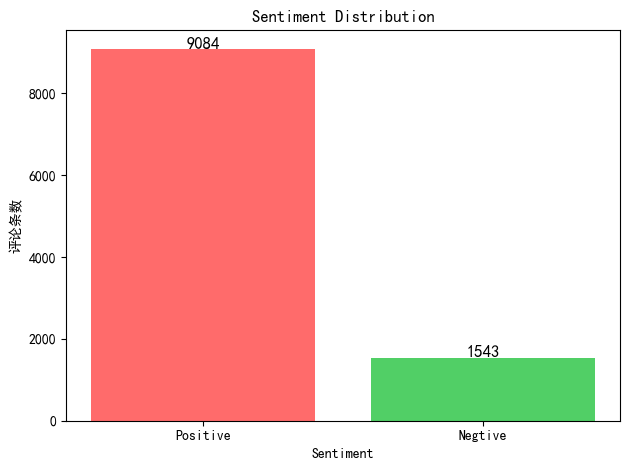

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# # 读取数据
# df = pd.read_excel("评价数据_抽取结果.xlsx")

# 找到评分列
score_col = [col for col in df.columns if '评分' in str(col)][0]

# 分类：负面（≤3分）vs 正面（≥4分）
df['情绪分类'] = df[score_col].apply(lambda x: 'Negtive' if x <= 3 else 'Positive')

# 统计数量
sentiment_counts = df['情绪分类'].value_counts()
print(sentiment_counts)

# 画柱状图
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#ff6b6b', '#51cf66'])
plt.xlabel('Sentiment')
plt.ylabel('评论条数')
plt.title('Sentiment Distribution')

# 显示数值
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('正负面评论对比.png', dpi=150)
plt.show()